In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
from nltk.corpus import stopwords
import spacy

# cleaning texts libraries
import re
import emoji

1092.951980295137
2930
32


<Axes: xlabel='text_length', ylabel='Count'>

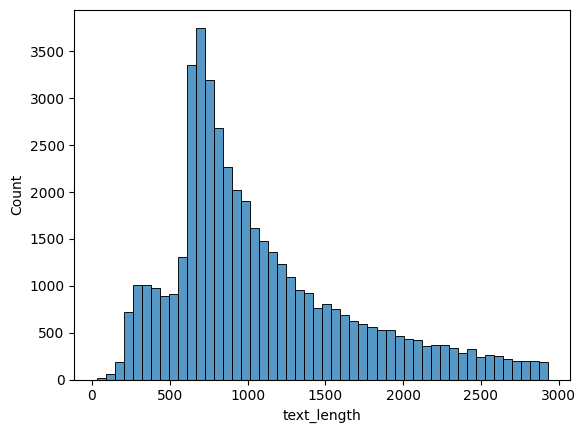

In [18]:
df = pd.read_csv('../Data/preprocessed_data.csv')


print(df['text_length'].mean())
print(df['text_length'].max())
print(df['text_length'].min())


sns.histplot(x=df['text_length'] , bins=50)

In [19]:
# loading spaCy

nlp = spacy.load('en_core_web_sm')

In [20]:
stop_words = set(stopwords.words('english'))

In [21]:
# Remove negations
negation_words = {'not' , 'no' , 'never'}

stop_words = stop_words - negation_words

In [22]:
def clean_text(text):
    # lower casing
    text = text.lower()

    # remove HTML
    text = re.sub(r'<.*?>' , '' , text)

    # remove urls
    text = re.sub(r'http\S+|www\s+' , '' , text)

    # convert emojis
    text = emoji.demojize(text)

    # remove puntuation * special chars
    text = re.sub(r'[^a-zA-Z\s]' , '' , text)

    # tokenization with spacy
    doc = nlp(text)

    tokens = []

    for token in doc:

        if (
            token.text not in stop_words and 
            not token.is_punct and
            not token.like_num and
            len(token.text) > 2
        ):
            tokens.append(token.lemma_)

    return " ".join(tokens)


In [23]:
sample = df['review'].iloc[0]

print(sample)

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [24]:
print(clean_text(sample))

reviewer mention watch episode hook right exactly happen methe thing strike brutality unflinche scene violence set right word trust not show faint hearted timid show pull punch regard drug sex violence hardcore classic use wordit call nickname give oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inward privacy not high agenda city home manyaryan muslims gangstas latinos christians italian irish moreso scuffle death stare dodgy dealing shady agreement never far awayi would say main appeal show due fact go show would dare forget pretty picture paint mainstream audience forget charm forget romanceoz mess around episode ever see strike nasty surreal could say ready watch develop taste get accustom high level graphic violence not violence injustice crook guard sell nickel inmate kill order get away well mannered middle class inmate turn prison bitch due lack street skill prison experience watch may become comfortable unco

In [25]:
df['cleaned_review'] = df['review'].apply(clean_text)

In [26]:
df.to_csv('../Data/cleaned_csv')